## Setup und Datenvorbereitung
Hier importieren wir alle notwendigen Bibliotheken und laden unser *Road Traffic* Dataset. Laut Tabelle enthält der Datensatz 6 Merkmale/Spalten; für die Regression ist `Cross 6` die Zielvariable (y), daher bleiben `Cross 1` bis `Cross 5` als Prädiktoren (X).

In [1]:
import statistics as st
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, accuracy_score
from sklearn.preprocessing import PolynomialFeatures

# Daten laden und benennen
road_traffic_df = pd.read_csv('traffic-prediction-dataset.csv')
road_traffic_df.columns = ['Cross 1', 'Cross 2', 'Cross 3', 'Cross 4', 'Cross 5', 'Cross 6']

# Laut Tabelle: 6 Merkmale/Spalten im Road-Traffic-Datensatz
dataset_columns = ['Cross 1', 'Cross 2', 'Cross 3', 'Cross 4', 'Cross 5', 'Cross 6']

# Fuer die Regression darf das Zielmerkmal nicht als Eingabe verwendet werden
features = ['Cross 1', 'Cross 2', 'Cross 3', 'Cross 4', 'Cross 5']
target = 'Cross 6'

X = road_traffic_df[features]
y = road_traffic_df[target]

## Aufgabe e

In [2]:
# Modell initialisieren und trainieren
lr_model = LinearRegression()
lr_model.fit(X, y)

# R^2-Score auf dem Gesamtdatensatz berechnen
y_pred = lr_model.predict(X)
r2 = r2_score(y, y_pred)

print(f"Bestimmtheitsmaß (R^2) mit 5 Prädiktoren aus 6 Datensatzmerkmalen: {r2:.4f}")

Bestimmtheitsmaß (R^2) mit 5 Prädiktoren aus 6 Datensatzmerkmalen: 0.8371


### Begründung zur Merkmalsauswahl
Die Tabelle und die Merkmalsanalyse aus Teil c sind hier maßgeblich: Der Road-Traffic-Datensatz besitzt 6 Merkmale/Spalten, und `Cross 6` ist das Zielmerkmal. Für das Regressionsmodell verwenden wir deshalb nur die verbleibenden fünf Prädiktoren (`Cross 1` bis `Cross 5`) als `X`. Kategorische Variablen gibt es in diesem Datensatz nicht, daher ist keine Umcodierung wie One-Hot-Encoding nötig. `Cross 6` zusätzlich als Eingabe zu verwenden, wäre Datenleckage und würde die Modellgüte künstlich aufblasen.


## Aufgabe f

,Trainingsanteil,Anzahl Trainingszeilen,Test-R²
0,10%,1290,0.828030
1,20%,2580,0.828814
2,40%,5160,0.828905
3,80%,10321,0.829938
4,100%,12902,0.830068


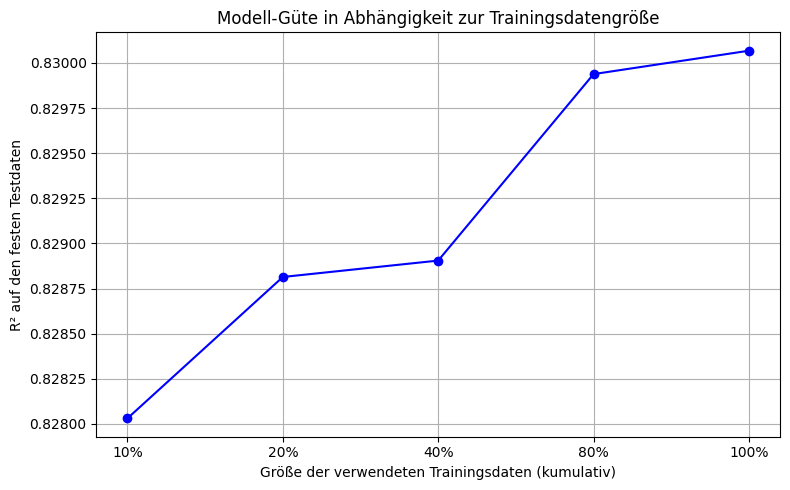

In [3]:
# 1. 80/20-Aufteilung in potentielle Trainingsdaten und feste Testdaten
X_train_pot, X_test, y_train_pot, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# 2. Kumulatives Zufalls-Sampling mit festem Seed
rng = np.random.default_rng(42)
all_indices = list(X_train_pot.index)
rng.shuffle(all_indices)

fractions = [0.10, 0.20, 0.40, 0.80, 1.00]
r2_scores = []
sizes = []
row_counts = []

# Da einmalig gemischt wird, enthält 20% automatisch die 10% aus dem Schritt davor plus neue Zeilen.
for frac in fractions:
    n = int(len(all_indices) * frac)
    subset_idx = all_indices[:n]

    X_train_sub = X_train_pot.loc[subset_idx]
    y_train_sub = y_train_pot.loc[subset_idx]

    model_f = LinearRegression()
    model_f.fit(X_train_sub, y_train_sub)

    score = r2_score(y_test, model_f.predict(X_test))
    r2_scores.append(score)
    sizes.append(f"{int(frac * 100)}%")
    row_counts.append(n)

results_f = pd.DataFrame({
    "Trainingsanteil": sizes,
    "Anzahl Trainingszeilen": row_counts,
    "Test-R²": r2_scores,
})
display(results_f)

# 3. Liniendiagramm plotten
plt.figure(figsize=(8, 5))
plt.plot(sizes, r2_scores, marker='o', linestyle='-', color='b')
plt.title("Modell-Güte in Abhängigkeit zur Trainingsdatengröße")
plt.xlabel("Größe der verwendeten Trainingsdaten (kumulativ)")
plt.ylabel("R² auf den festen Testdaten")
plt.grid(True)
plt.tight_layout()
plt.show()


### Beobachtung und Modell-Empfehlung

**Was ist zu beobachten?**
Die Test-R²-Werte liegen sehr nah beieinander. Die Modellgüte steigt nur leicht von ca. 0.8280 auf ca. 0.8301 und flacht praktisch sofort ab. Das heißt: Schon ein kleinerer Trainingsanteil reicht aus, um den linearen Zusammenhang recht stabil zu lernen; zusätzliche Daten bringen hier nur noch eine minimale Verbesserung.

**Welches Modell empfehle ich und warum?**
Ich empfehle trotzdem das Modell mit **100% der potentiellen Trainingsdaten** (also 80% des Gesamtdatensatzes), weil es den höchsten Test-R² erreicht und auf der größten Datenbasis trainiert wurde. Die Verbesserung ist aber klein. Zu behaupten, es gebe einen starken Qualitätssprung, wäre fachlich falsch.


## Aufgabe g

Das beste Einzelmerkmal für y ist: 'Cross 1' (höchstes univariates Train-R² = 0.8249)


,Merkmal,Train-R²
0,Cross 1,0.824881
2,Cross 3,0.737753
3,Cross 4,0.671609
4,Cross 5,0.656580
1,Cross 2,0.618807


,Polynomgrad,Train-R²,Test-R²
0,1,0.824881,0.817364
1,2,0.843962,0.837714
2,3,0.843963,0.837703


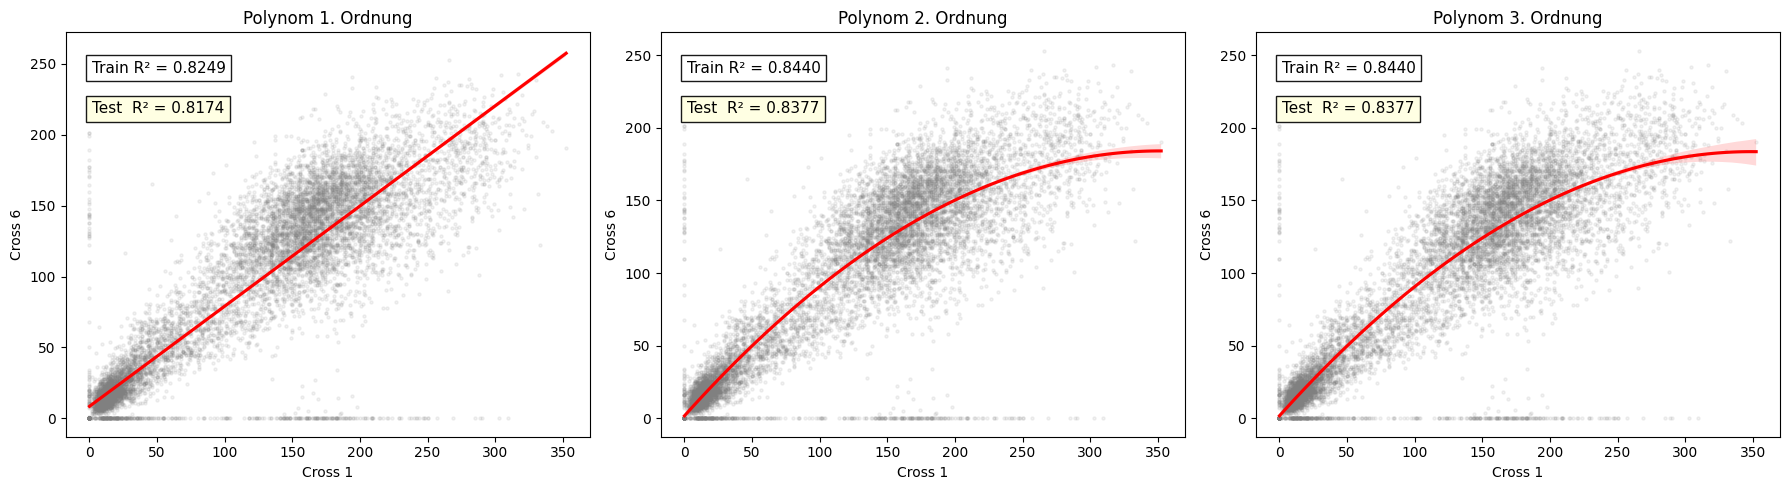

In [4]:
# 1. Bestes relevantes Einzelmerkmal univariat evaluieren
best_feature = None
best_r2 = -float("inf")
single_feature_scores = []

for col in X_train_pot.columns:
    model_g_uni = LinearRegression()
    X_uni = X_train_pot[[col]]
    model_g_uni.fit(X_uni, y_train_pot)

    pred_uni = model_g_uni.predict(X_uni)
    score = r2_score(y_train_pot, pred_uni)
    single_feature_scores.append((col, score))

    if score > best_r2:
        best_r2 = score
        best_feature = col

single_feature_df = pd.DataFrame(single_feature_scores, columns=["Merkmal", "Train-R²"])
display(single_feature_df.sort_values("Train-R²", ascending=False))
print(f"Das beste Einzelmerkmal für y ist: '{best_feature}' (höchstes univariates Train-R² = {best_r2:.4f})")

# 2. Visualisierung der polynomialen Regression (Grad 1 bis 3)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
orders = [1, 2, 3]
poly_scores = []

for degree, ax in zip(orders, axes):
    sns.regplot(
        x=X_train_pot[best_feature],
        y=y_train_pot,
        order=degree,
        ax=ax,
        scatter_kws={'alpha': 0.1, 'color': 'gray', 's': 5},
        line_kws={'color': 'red'}
    )
    ax.set_title(f"Polynom {degree}. Ordnung")

    poly = PolynomialFeatures(degree=degree)
    X_poly_train = poly.fit_transform(X_train_pot[[best_feature]])

    poly_model = LinearRegression()
    poly_model.fit(X_poly_train, y_train_pot)

    r2_poly_train = r2_score(y_train_pot, poly_model.predict(X_poly_train))
    X_poly_test = poly.transform(X_test[[best_feature]])
    r2_poly_test = r2_score(y_test, poly_model.predict(X_poly_test))
    poly_scores.append((degree, r2_poly_train, r2_poly_test))

    ax.text(0.05, 0.90, f"Train R² = {r2_poly_train:.4f}", transform=ax.transAxes,
            fontsize=11, bbox=dict(facecolor='white', alpha=0.9))
    ax.text(0.05, 0.80, f"Test  R² = {r2_poly_test:.4f}", transform=ax.transAxes,
            fontsize=11, bbox=dict(facecolor='lightyellow', alpha=0.9))

plt.tight_layout()
plt.show()

poly_scores_df = pd.DataFrame(poly_scores, columns=["Polynomgrad", "Train-R²", "Test-R²"])
display(poly_scores_df)


### Begründung des Merkmals und Beurteilung Under- und Overfitting

**Wahl des Merkmals:** `Cross 1` wird anhand der potentiellen Trainingsdaten ausgewählt, weil es unter den einzelnen Prädiktoren das höchste univariate Train-R² erreicht. Damit erklärt `Cross 1` allein den größten Anteil der Varianz von `Cross 6`.

**Wie schlagen sich die Modelle (Under- vs. Overfitting)?**
- **Polynom 1. Ordnung (linear):** Das Modell erreicht ca. 0.825 Train-R² und ca. 0.817 Test-R². Es ist solide, bildet aber die erkennbare Krümmung nur begrenzt ab. Deshalb liegt leichtes Underfitting vor.
- **Polynom 2. Ordnung (quadratisch):** Das Modell verbessert sich auf ca. 0.844 Train-R² und ca. 0.838 Test-R². Da Train- und Testwert nah beieinander bleiben, ist das hier der beste Kompromiss.
- **Polynom 3. Ordnung (kubisch):** Die Werte bleiben praktisch identisch zu Grad 2. Es gibt kein klares Overfitting-Signal, aber auch keinen echten Mehrwert. Grad 3 ist daher unnötig komplex.


## Aufgabe h

In [5]:
# 1. Erst in Roh-Zielwerte splitten, dann den Schwellenwert nur aus den Trainingsdaten bestimmen
X_train_cls, X_test_cls, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=(1/3), random_state=42
)

threshold = y_train_raw.median()
y_train_cls = (y_train_raw > threshold).astype(int)
y_test_cls = (y_test_raw > threshold).astype(int)

# 2. Logistische Regression
log_reg = LogisticRegression(solver='lbfgs', max_iter=2000)
log_reg.fit(X_train_cls, y_train_cls)

# 3. Genauigkeit ermitteln
acc_train = accuracy_score(y_train_cls, log_reg.predict(X_train_cls))
acc_test = accuracy_score(y_test_cls, log_reg.predict(X_test_cls))

print(f"Genutzter Klassifikations-Schwellenwert aus Trainingsdaten (Median): {threshold}")
print(f"Accuracy auf Trainingsdaten: {acc_train:.4f}")
print(f"Accuracy auf Testdaten: {acc_test:.4f}")


Genutzter Klassifikations-Schwellenwert aus Trainingsdaten (Median): 65.75
Accuracy auf Trainingsdaten: 0.9513
Accuracy auf Testdaten: 0.9526


### Urteil und Möglichkeiten zur Leistungssteigerung

**Sind wir zufrieden?**
Die Genauigkeit liegt mit ca. **95,13% auf den Trainingsdaten** und ca. **95,26% auf den Testdaten** hoch. Für diese einfache binäre Einteilung ist das Modell brauchbar. Trotzdem sollte man nicht behaupten, das Modell sei "fast perfekt": Accuracy allein zeigt nicht, welche Fehlerarten auftreten, und eine leicht höhere Test-Accuracy beweist nicht automatisch, dass keinerlei Overfitting möglich ist.

**Wie können wir die Performance weiter steigern oder robuster bewerten?**
1. **Feature Scaling (`StandardScaler`):** Für logistische Regression ist Skalierung sinnvoll, weil die Optimierung stabiler wird und Merkmale vergleichbarer werden.
2. **Hyperparameter-Tuning:** Der Regularisierungsparameter `C` kann per Grid-Search oder Cross-Validation optimiert werden.
3. **Bessere Bewertung:** Zusätzlich zur Accuracy sollten Confusion Matrix, Precision und Recall betrachtet werden.
4. **Klassengrenze prüfen:** Der Median-Split ist technisch sauber, aber fachlich willkürlich. Je nach Fragestellung könnte eine Grenze für hohe Verkehrslast sinnvoller sein.
